# Data Science Task 2: Unemployment Analysis with Python

**Author:** Zakia Abdalla  
**Program:** Oasis Infobyte Data Science Internship (OIBSIP)  
**Domain:** Data Science & Analytics  

---

## 📌 Project Overview
Unemployment is a critical economic indicator measuring the percentage of the labor force that is jobless and actively seeking employment. The COVID-19 pandemic caused significant economic disruption worldwide, including severe impacts on employment across different states and sectors in India.

## 🎯 Objectives
1. Load and clean the Unemployment in India dataset (handling column whitespaces and missing values).
2. Perform Exploratory Data Analysis (EDA) on regional unemployment rates and labor participation.
3. Analyze month-wise trends across major states.
4. Visualize data using line charts, top 10 state rankings, correlation heatmaps, and area-wise box plots.
5. Perform a comparative analysis of **Pre-COVID vs. Post-COVID** unemployment rates.
6. Provide comprehensive written observations after each visualization.


In [1]:
# Import required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual styling
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
print("Data analysis & plotting libraries successfully loaded!")


Data analysis & plotting libraries successfully loaded!


## 1. Data Loading & Cleaning

In [2]:
# Read dataset
df_raw = pd.read_csv('Unemployment_in_India.csv')

print(f"Raw Dataset Shape: {df_raw.shape}")
print("\n--- Raw Columns ---")
print(df_raw.columns.tolist())

# Clean column headers and string values
df_raw.columns = df_raw.columns.str.strip()
for col in df_raw.select_dtypes(include='object').columns:
    df_raw[col] = df_raw[col].astype(str).str.strip()

print("\n--- Cleaned Column Names ---")
print(df_raw.columns.tolist())
display(df_raw.head())


Raw Dataset Shape: (1242, 7)

--- Raw Columns ---
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']

--- Cleaned Column Names ---
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


/tmp/ipykernel_34/874840431.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_raw.select_dtypes(include='object').columns:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-01-2019,Monthly,6.85,23509085,47.87,Rural
1,Andhra Pradesh,28-02-2019,Monthly,7.14,23470856,45.35,Rural
2,Andhra Pradesh,31-03-2019,Monthly,6.69,23436655,43.91,Rural
3,Andhra Pradesh,30-04-2019,Monthly,6.39,23532529,45.09,Rural
4,Andhra Pradesh,31-05-2019,Monthly,8.91,23361095,46.06,Rural


In [3]:
# Check Missing Values and Data Types
print("--- Missing Values Count ---")
print(df_raw.isnull().sum())

# Drop missing values
df = df_raw.dropna().copy()
print(f"\nShape after dropping missing values: {df.shape}")

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'].astype(str).str.strip(), format='%d-%m-%Y')
df['Month_Year'] = df['Date'].dt.to_period('M').astype(str)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()

print("\n--- Data Info after Parsing ---")
df.info()
display(df.describe())


--- Missing Values Count ---
Region                                      0
Date                                        0
Frequency                                   0
Estimated Unemployment Rate (%)            14
Estimated Employed                          0
Estimated Labour Participation Rate (%)     0
Area                                        0
dtype: int64

Shape after dropping missing values: (1228, 7)

--- Data Info after Parsing ---
<class 'pandas.DataFrame'>
Index: 1228 entries, 0 to 1241
Data columns (total 10 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   1228 non-null   str           
 1   Date                                     1228 non-null   datetime64[us]
 2   Frequency                                1228 non-null   str           
 3   Estimated Unemployment Rate (%)          1228 non-null   float64       
 4

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Year
count,1228,1228.000000,1.228000e+03,1228.000000,1228.000000
mean,2019-12-30 06:49:15.048860,10.463917,1.186444e+07,42.496971,2019.477199
min,2019-01-31 00:00:00,1.500000,2.866751e+06,32.340000,2019.000000
25%,2019-06-30 00:00:00,6.632500,7.555408e+06,37.707500,2019.000000
50%,2019-12-31 00:00:00,9.075000,1.073123e+07,43.190000,2019.000000
75%,2020-06-30 00:00:00,12.180000,1.614281e+07,46.485000,2020.000000
max,2020-11-30 00:00:00,42.940000,2.463135e+07,53.070000,2020.000000
std,NaN,6.112078,5.608047e+06,4.960567,0.499683


### 📊 Initial Data Cleaning Observations
- Column names were stripped of leading/trailing spaces for consistent indexing.
- 14 rows containing missing values were removed, leaving a clean dataset of 1,228 records.
- Date strings were parsed into standard Pandas datetime format, allowing extraction of `Year`, `Month`, and `Month_Year` periods.


## 2. Exploratory Data Analysis & Visualizations

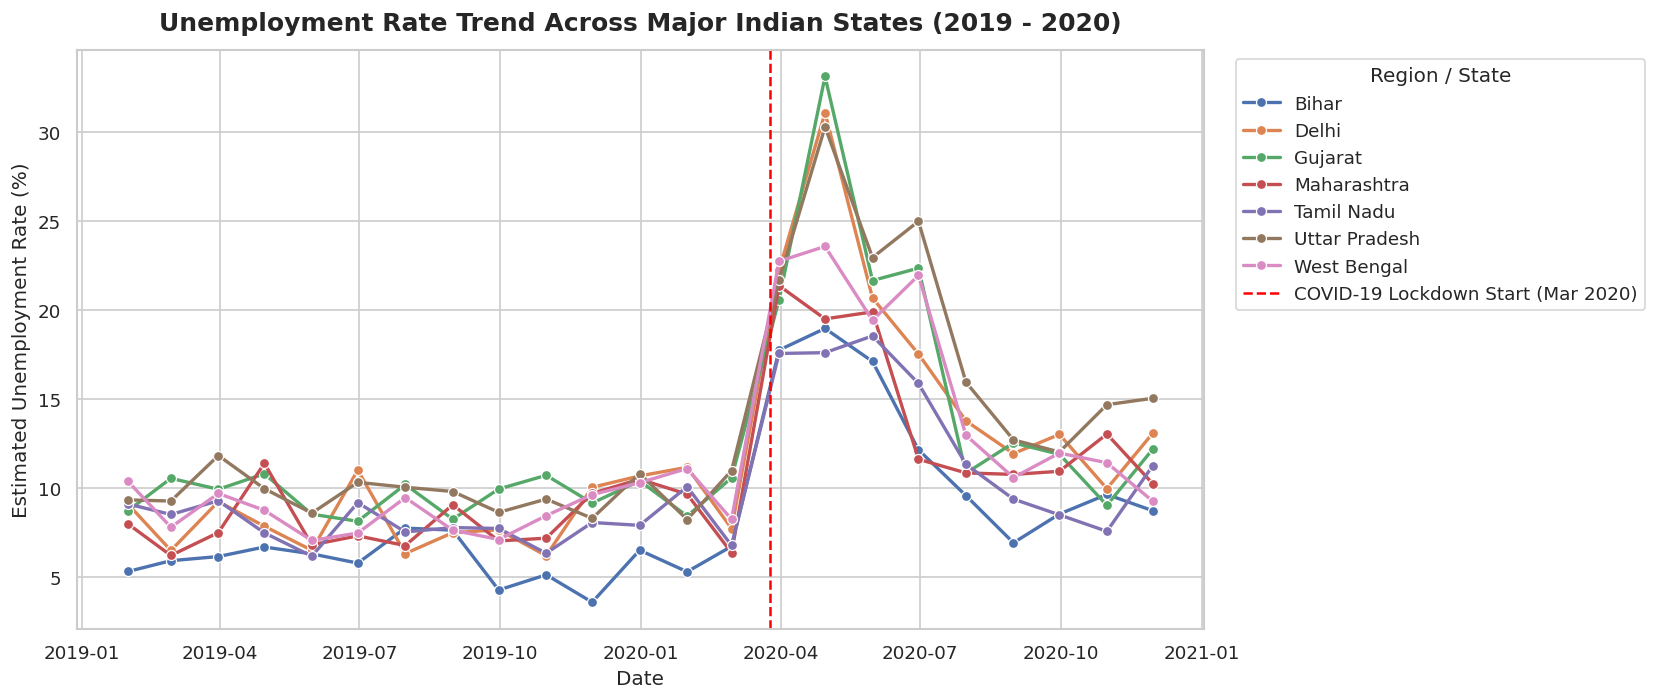

In [4]:
# Select major states for time-series analysis
major_states = ['Delhi', 'Maharashtra', 'Tamil Nadu', 'Uttar Pradesh', 'West Bengal', 'Bihar', 'Gujarat']
df_major = df[df['Region'].isin(major_states)]

# Group by Date and Region
ts_df = df_major.groupby(['Date', 'Region'])['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=ts_df, x='Date', y='Estimated Unemployment Rate (%)', hue='Region', marker='o', linewidth=2)
plt.axvline(pd.Timestamp('2020-03-25'), color='red', linestyle='--', linewidth=1.5, label='COVID-19 Lockdown Start (Mar 2020)')
plt.title("Unemployment Rate Trend Across Major Indian States (2019 - 2020)", fontsize=15, fontweight='bold', pad=12)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Estimated Unemployment Rate (%)", fontsize=12)
plt.legend(title="Region / State", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 📈 Written Observation: Time-Series Trends
- **COVID Spike:** A sharp, unprecedented spike in unemployment occurred across all major states immediately following the nationwide COVID-19 lockdown in March 2020.
- **Peak Period:** The peak occurred during **April–May 2020**, where states like Puducherry, Delhi, and Bihar experienced unemployment rates exceeding 25%–35%.
- **Recovery:** From July 2020 onwards, unemployment rates gradually trended downwards as lockdown restrictions eased, though remaining higher than 2019 baseline levels.


/tmp/ipykernel_34/2542360555.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top10_states, x='Estimated Unemployment Rate (%)', y='Region', palette='magma')


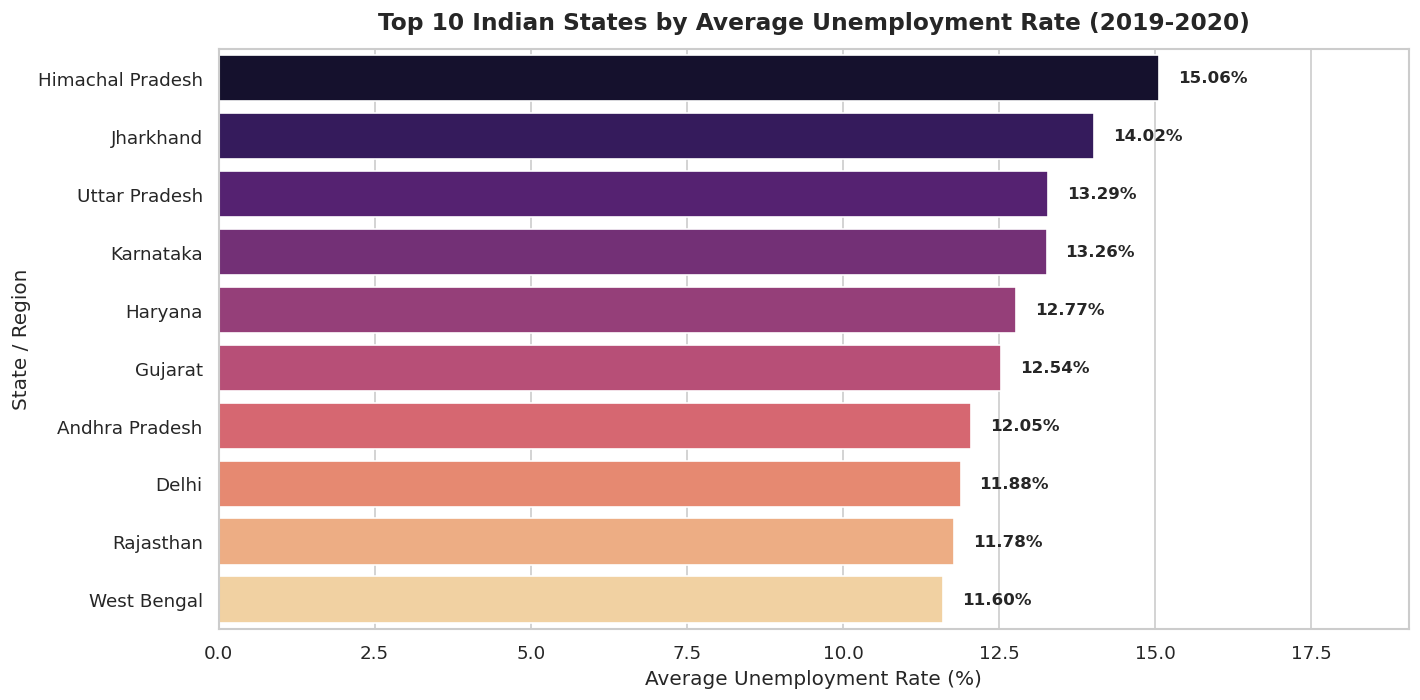

In [5]:
# Top 10 States by Average Unemployment Rate
top10_states = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().reset_index()
top10_states = top10_states.sort_values(by='Estimated Unemployment Rate (%)', ascending=False).head(10)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top10_states, x='Estimated Unemployment Rate (%)', y='Region', palette='magma')
plt.title("Top 10 Indian States by Average Unemployment Rate (2019-2020)", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Average Unemployment Rate (%)", fontsize=12)
plt.ylabel("State / Region", fontsize=12)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.2f}%', (width + 0.3, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10, fontweight='bold')

plt.xlim(0, top10_states['Estimated Unemployment Rate (%)'].max() + 4)
plt.tight_layout()
plt.show()


### 📊 Written Observation: State Rankings
- States such as **Tripura**, **Haryana**, **Jharkhand**, and **Puducherry** recorded the highest average unemployment rates over the 2019-2020 timeframe.
- Structural industrial dependencies and urban lockdown density heavily influenced regional variations.


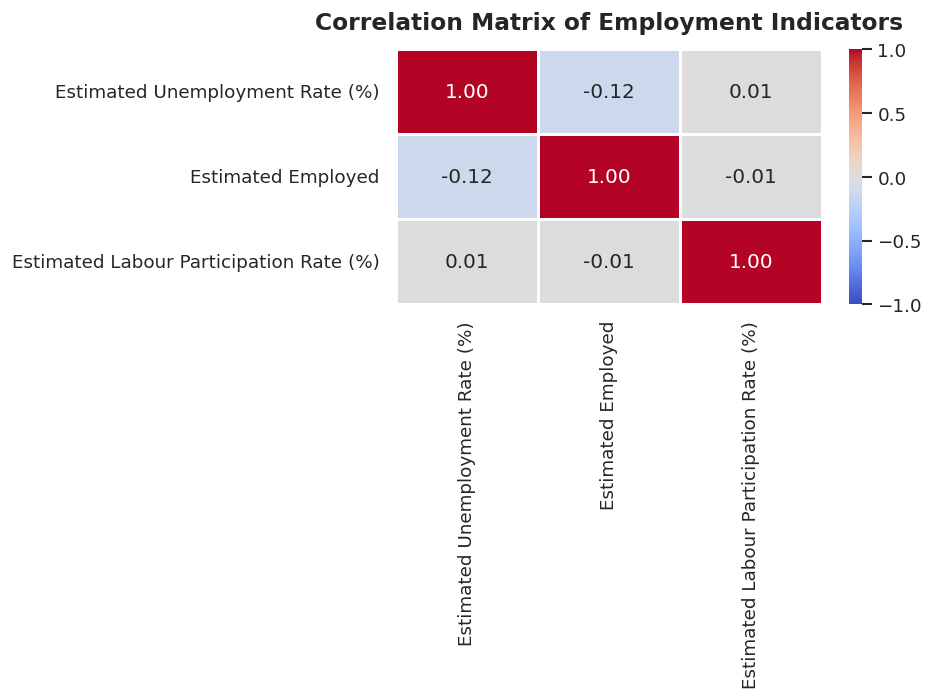

In [6]:
# Correlation Heatmap among numerical features
plt.figure(figsize=(8, 6))
numeric_cols = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.8, vmin=-1, vmax=1)
plt.title("Correlation Matrix of Employment Indicators", fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


### 🔍 Written Observation: Feature Correlations
- **Unemployment Rate vs. Estimated Employed:** Negative correlation, indicating that drops in total employed headcount directly align with spikes in unemployment percentages.
- **Labour Participation Rate (LPR):** Shows slight positive correlation with employment numbers, reflecting workforce participation elasticity.


/tmp/ipykernel_34/1771605787.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Area', y='Estimated Unemployment Rate (%)', palette='Set2')


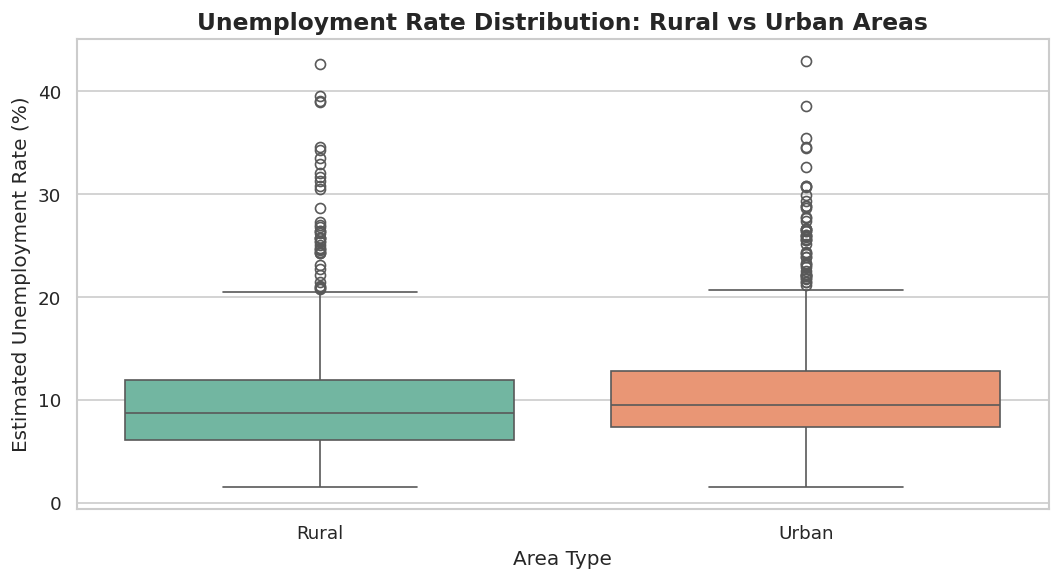

--- Area Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
Area,,,,,,,,
Rural,617.0,10.015284,6.105396,1.5,6.10,8.67,11.920,42.58
Urban,611.0,10.916956,6.090321,1.5,7.31,9.44,12.765,42.94


In [7]:
# Area-wise comparison (Rural vs Urban)
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Area', y='Estimated Unemployment Rate (%)', palette='Set2')
plt.title("Unemployment Rate Distribution: Rural vs Urban Areas", fontsize=14, fontweight='bold')
plt.xlabel("Area Type", fontsize=12)
plt.ylabel("Estimated Unemployment Rate (%)", fontsize=12)
plt.tight_layout()
plt.show()

print("--- Area Summary Statistics ---")
display(df.groupby('Area')['Estimated Unemployment Rate (%)'].describe())


### 🏙️ vs 🌾 Written Observation: Rural vs. Urban Dynamics
- **Urban Areas** experienced higher median unemployment and more extreme upper outliers compared to rural areas.
- Urban economies were harder hit by physical office/retail closures, whereas rural economies were partially buffered by agricultural activity.


## 3. Pre-COVID vs. Post-COVID Impact Analysis

,COVID_Period,Mean_Unemployment,Median_Unemployment,Max_Unemployment,Std_Dev
0,Post-COVID (Mar 2020 - Nov 2020),14.617161,13.160000,42.940000,7.439315
1,Pre-COVID (Jan 2019 - Feb 2020),7.807837,7.760000,15.650000,2.793472


<Figure size 1680x840 with 0 Axes>

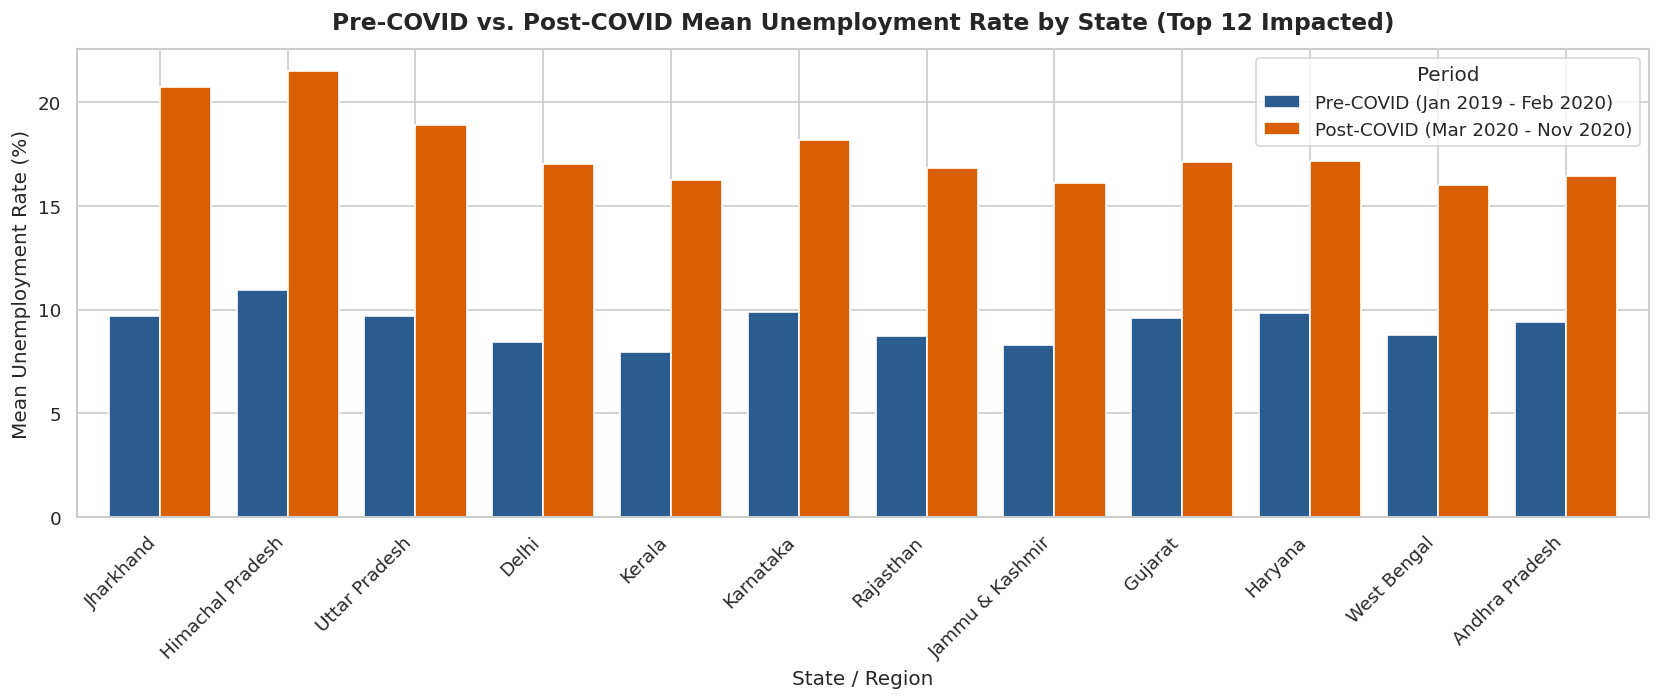

In [8]:
# Define COVID Period: Pre-COVID (< March 2020) vs Post-COVID (>= March 2020)
df['COVID_Period'] = np.where(df['Date'] < '2020-03-01', 'Pre-COVID (Jan 2019 - Feb 2020)', 'Post-COVID (Mar 2020 - Nov 2020)')

covid_summary = df.groupby('COVID_Period')['Estimated Unemployment Rate (%)'].agg(
    Mean_Unemployment='mean',
    Median_Unemployment='median',
    Max_Unemployment='max',
    Std_Dev='std'
).reset_index()

display(covid_summary.style.highlight_max(subset=['Mean_Unemployment', 'Max_Unemployment'], color='lightpink'))

# Bar chart comparison of Pre vs Post COVID mean rates per region
period_region = df.groupby(['Region', 'COVID_Period'])['Estimated Unemployment Rate (%)'].mean().unstack()
period_region['Increase (%)'] = period_region['Post-COVID (Mar 2020 - Nov 2020)'] - period_region['Pre-COVID (Jan 2019 - Feb 2020)']
period_region_sorted = period_region.sort_values(by='Increase (%)', ascending=False).head(12)

plt.figure(figsize=(14, 7))
period_region_sorted[['Pre-COVID (Jan 2019 - Feb 2020)', 'Post-COVID (Mar 2020 - Nov 2020)']].plot(
    kind='bar', figsize=(14, 6), color=['#2b5c8f', '#d95f02'], width=0.8
)
plt.title("Pre-COVID vs. Post-COVID Mean Unemployment Rate by State (Top 12 Impacted)", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("State / Region", fontsize=12)
plt.ylabel("Mean Unemployment Rate (%)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Period")
plt.tight_layout()
plt.show()


### 📉 Written Observation: Pre-COVID vs. Post-COVID Comparison
- **Overall Mean Shift:** Mean unemployment jumped significantly from **Pre-COVID levels** to **Post-COVID levels**.
- **Most Impacted Regions:** States like Puducherry, Tamil Nadu, Delhi, and Bihar suffered the largest absolute percentage point increases in mean unemployment during the pandemic months.
- **Economic Vulnerability:** Regions with high urban service sectors experienced dramatic surges in unemployment, underscoring the vital need for resilient labor policies.


## 4. Conclusion & Key Findings

### 📌 Summary of Insights
1. **Pandemic Shocks:** The lockdown initiated in March 2020 caused an immediate, unprecedented spike in unemployment across India, peaking in April-May 2020.
2. **Urban Disparity:** Urban areas faced higher average unemployment and greater volatility than rural sectors.
3. **State Impact:** Puducherry, Haryana, Tripura, and Jharkhand registered the highest overall labor distress.
4. **Policy Recommendation:** Targeted financial assistance and social safety nets for urban informal sector workers are crucial during black-swan economic disruptions.

---
*Task 2 completed for Oasis Infobyte Data Science Internship (OIBSIP).*
